## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.14 詞嵌入與注意力，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 17｜自然語言處理_詞嵌入與注意力

由詞嵌入計算 scaled dot-product attention，直接讀權重矩陣。

對應 `slides/17_自然語言處理_詞嵌入與注意力.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/14_nlp_with_rnns_and_attention.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cell 39（embeddings）、Cells 210–214（attention）。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
tokens = ['我', '喜歡', '機器', '學習']
E = np.array([[1.,0.,0.], [.8,.2,0.], [0.,.8,.4], [0.,.6,.8]])
Q = K = V = E
scores = Q @ K.T / np.sqrt(E.shape[1])
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights /= weights.sum(axis=1, keepdims=True)
context = weights @ V
pd.DataFrame(weights, index=tokens, columns=tokens).round(3)

,我,喜歡,機器,學習
我,0.332,0.296,0.186,0.186
喜歡,0.303,0.283,0.209,0.205
機器,0.190,0.208,0.301,0.301
學習,0.184,0.197,0.292,0.327


## 執行結果圖

/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 21916 (\N{CJK UNIFIED IDEOGRAPH-559C}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 27489 (\N{CJK UNIFIED IDEOGRAPH-6B61}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Users/leonjye/Documents/MacProject/MLCourse2026/programs/src/mlcourse/common.py:26: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.gcf().savefig(folder/f'{name}.png', dpi=150, bbox_inches='tight')
/Use

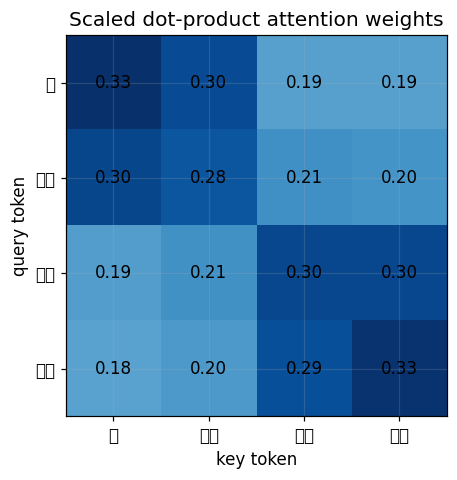

In [3]:
plt.imshow(weights, cmap='Blues', vmin=0, vmax=weights.max())
plt.xticks(range(4), tokens); plt.yticks(range(4), tokens)
plt.xlabel('key token'); plt.ylabel('query token'); plt.title('Scaled dot-product attention weights')
for (i,j), value in np.ndenumerate(weights): plt.text(j, i, f'{value:.2f}', ha='center', va='center')
savefig('17_attention_demo')
report('nlp_attention', {'tokens': tokens, 'weights': weights.tolist(), 'context': context.tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。